# Holiday Planner - Weather Analysis

This notebook uses the Open-Meteo API to collect and compare weather data for multiple holiday destinations.

The aim is to support destination recommendations based on:
- Latitude and longitude
- Country
- Maximum temperature
- Humidity
- Cloudiness
- Wind speed

## Imports

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

## Destinations

In [10]:
locations_df = pd.read_csv("location.csv")
locations_df.head(30)

,Country,City
0,Mexico,Tulum
1,Mexico,Cancún
2,Mexico,Mexico City
3,South Africa,Cape Town
4,South Africa,Durban
5,South Africa,Johannesburg
6,Indonesia,Canggu
7,Indonesia,Ubud
8,Indonesia,Seminyak
9,Brazil,Rio de Janeiro


In [11]:
def get_location(place_name):
    url = "https://geocoding-api.open-meteo.com/v1/search"
    
    params = {
        "name": place_name,
        "count": 1,
        "language": "en",
        "format": "json"}
    
    response = requests.get(url, params=params)
    data = response.json()
    
    if "results" in data and len(data["results"]) > 0:
        result = data["results"][0]
        
        return {
            "destination": place_name,
            "latitude": result.get("latitude"),
            "longitude": result.get("longitude"),
            "country": result.get("country")}
    else:
        return None

In [12]:
get_location("Kyoto, Japan")

{'destination': 'Kyoto, Japan',
 'latitude': 35.02107,
 'longitude': 135.75385,
 'country': 'Japan'}

In [13]:
def get_weather(lat, lon):
    url = "https://api.open-meteo.com/v1/forecast"
    
    params = {
        "latitude": lat,
        "longitude": lon,
        "current": "relative_humidity_2m,cloud_cover,wind_speed_10m",
        "daily": "temperature_2m_max,wind_speed_10m_max",
        "timezone": "auto",
        "forecast_days": 7
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    daily_max_temps = data["daily"]["temperature_2m_max"]
    daily_max_winds = data["daily"]["wind_speed_10m_max"]
    
    return {
        "avg_max_temp_7_days": sum(daily_max_temps) / len(daily_max_temps),
        "current_humidity": data["current"].get("relative_humidity_2m"),
        "current_cloudiness": data["current"].get("cloud_cover"),
        "current_wind_speed": data["current"].get("wind_speed_10m"),
        "avg_max_wind_7_days": sum(daily_max_winds) / len(daily_max_winds)}

In [14]:
test_location = get_location("Kyoto, Japan")
get_weather(test_location["latitude"], test_location["longitude"])

{'avg_max_temp_7_days': 19.142857142857142,
 'current_humidity': 91,
 'current_cloudiness': 58,
 'current_wind_speed': 4.3,
 'avg_max_wind_7_days': 11.157142857142858}

In [18]:
locations_df.columns = locations_df.columns.str.strip()
print(locations_df.columns)

Index(['Country', 'City'], dtype='object')


In [20]:
results = []

for _, row in locations_df.iterrows():
    place_name = f"{row['City']}, {row['Country']}"
    location_data = get_location(place_name)
    
    if location_data is not None:
        weather_data = get_weather(location_data["latitude"], location_data["longitude"])
        
        combined_data = {
            "city": row["City"],
            "country_csv": row["Country"],
            **location_data,
            **weather_data}
        
        results.append(combined_data)

In [16]:
print(locations_df.columns)

Index(['Country ', 'City'], dtype='object')


In [21]:
df_weather = pd.DataFrame(results)
df_weather = df_weather.round(2)
df_weather

,city,country_csv,destination,latitude,longitude,country,avg_max_temp_7_days,current_humidity,current_cloudiness,current_wind_speed,avg_max_wind_7_days
0,Tulum,Mexico,"Tulum, Mexico",20.21,-87.46,Mexico,32.49,76,69,7.5,13.76
1,Cancún,Mexico,"Cancún, Mexico",21.17,-86.85,Mexico,32.41,75,54,7.9,13.50
2,Mexico City,Mexico,"Mexico City, Mexico",19.43,-99.13,Mexico,28.00,66,25,3.1,14.56
3,Cape Town,South Africa,"Cape Town, South Africa",-33.93,18.42,South Africa,18.04,45,0,7.9,20.80
4,Durban,South Africa,"Durban, South Africa",-29.86,31.03,South Africa,22.09,80,99,2.5,11.16
5,Johannesburg,South Africa,"Johannesburg, South Africa",-26.20,28.04,South Africa,19.54,62,100,13.4,14.84
6,Canggu,Indonesia,"Canggu, Indonesia",-7.75,112.22,Indonesia,32.50,94,100,3.4,9.84
7,Ubud,Indonesia,"Ubud, Indonesia",-8.51,115.27,Indonesia,29.04,96,81,4.7,10.30
8,Seminyak,Indonesia,"Seminyak, Indonesia",-8.69,115.16,Indonesia,28.61,85,100,9.7,13.54
9,Rio de Janeiro,Brazil,"Rio de Janeiro, Brazil",-22.91,-43.18,Brazil,32.04,58,29,0.4,9.67


In [22]:
df_weather.sort_values(by="avg_max_temp_7_days", ascending=False)

,city,country_csv,destination,latitude,longitude,country,avg_max_temp_7_days,current_humidity,current_cloudiness,current_wind_speed,avg_max_wind_7_days
17,Krabi,Thailand,"Krabi, Thailand",8.07,98.91,Thailand,35.17,78,48,5.8,13.27
16,Bangkok,Thailand,"Bangkok, Thailand",13.75,100.50,Thailand,34.91,80,51,11.9,11.96
6,Canggu,Indonesia,"Canggu, Indonesia",-7.75,112.22,Indonesia,32.50,94,100,3.4,9.84
0,Tulum,Mexico,"Tulum, Mexico",20.21,-87.46,Mexico,32.49,76,69,7.5,13.76
1,Cancún,Mexico,"Cancún, Mexico",21.17,-86.85,Mexico,32.41,75,54,7.9,13.50
9,Rio de Janeiro,Brazil,"Rio de Janeiro, Brazil",-22.91,-43.18,Brazil,32.04,58,29,0.4,9.67
15,Phuket,Thailand,"Phuket, Thailand",7.89,98.40,Thailand,31.17,77,40,8.8,12.51
7,Ubud,Indonesia,"Ubud, Indonesia",-8.51,115.27,Indonesia,29.04,96,81,4.7,10.30
25,Honolulu,United States,"Honolulu, United States",21.31,-157.86,United States,28.93,85,35,4.4,16.34
8,Seminyak,Indonesia,"Seminyak, Indonesia",-8.69,115.16,Indonesia,28.61,85,100,9.7,13.54


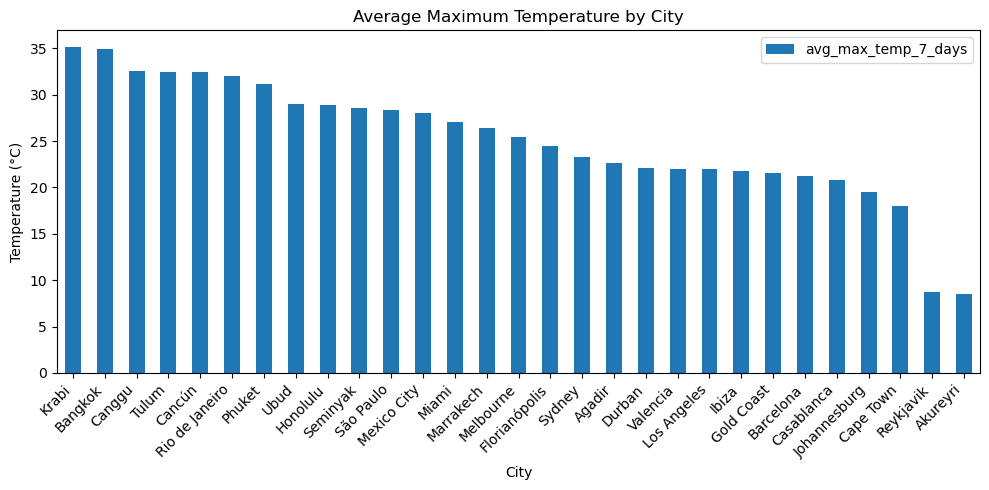

In [25]:
df_weather.sort_values("avg_max_temp_7_days", ascending=False).plot(
    x="city",
    y="avg_max_temp_7_days",
    kind="bar",
    figsize=(10, 5))

plt.title("Average Maximum Temperature by City")
plt.xlabel("City")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Initial Findings

The destinations show clear differences in average maximum temperature,
humidity, cloudiness, and wind speed.

This provides a first comparison of weather suitability across the selected
holiday options and can support further recommendation when combined with
cost and location-based data.

## Scoring system 

In [26]:
df_weather = pd.DataFrame(results)
df_weather = df_weather.round(2)
df_weather.head()

,city,country_csv,destination,latitude,longitude,country,avg_max_temp_7_days,current_humidity,current_cloudiness,current_wind_speed,avg_max_wind_7_days
0,Tulum,Mexico,"Tulum, Mexico",20.21,-87.46,Mexico,32.49,76,69,7.5,13.76
1,Cancún,Mexico,"Cancún, Mexico",21.17,-86.85,Mexico,32.41,75,54,7.9,13.50
2,Mexico City,Mexico,"Mexico City, Mexico",19.43,-99.13,Mexico,28.00,66,25,3.1,14.56
3,Cape Town,South Africa,"Cape Town, South Africa",-33.93,18.42,South Africa,18.04,45,0,7.9,20.80
4,Durban,South Africa,"Durban, South Africa",-29.86,31.03,South Africa,22.09,80,99,2.5,11.16


In [27]:
# Temperature: higher is better
df_weather["temp_score"] = (
    (df_weather["avg_max_temp_7_days"] - df_weather["avg_max_temp_7_days"].min()) /
    (df_weather["avg_max_temp_7_days"].max() - df_weather["avg_max_temp_7_days"].min()))

# Cloudiness: lower is better
df_weather["cloud_score"] = 1 - (
    (df_weather["current_cloudiness"] - df_weather["current_cloudiness"].min()) /
    (df_weather["current_cloudiness"].max() - df_weather["current_cloudiness"].min()))

# Wind speed: lower is better
df_weather["wind_score"] = 1 - (
    (df_weather["current_wind_speed"] - df_weather["current_wind_speed"].min()) /
    (df_weather["current_wind_speed"].max() - df_weather["current_wind_speed"].min()))

# Humidity: moderate is better
ideal_humidity = 60
df_weather["humidity_score"] = 1 - (
    abs(df_weather["current_humidity"] - ideal_humidity) /
    abs(df_weather["current_humidity"] - ideal_humidity).max())

In [29]:
df_weather["weather_score"] = (
    df_weather["temp_score"] * 0.4 +
    df_weather["cloud_score"] * 0.2 +
    df_weather["wind_score"] * 0.2 +
    df_weather["humidity_score"] * 0.2)

In [30]:
df_weather["weather_score"] = (df_weather["weather_score"] * 100).round(2)

In [31]:
def label_weather(score):
    if score >= 75:
        return "Excellent"
    elif score >= 60:
        return "Good"
    elif score >= 45:
        return "Average"
    else:
        return "Less Suitable"

df_weather["weather_rating"] = df_weather["weather_score"].apply(label_weather)

In [32]:
df_weather = df_weather.sort_values(by="weather_score", ascending=False)
df_weather[[
    "city",
    "country",
    "avg_max_temp_7_days",
    "current_humidity",
    "current_cloudiness",
    "current_wind_speed",
    "weather_score",
    "weather_rating"
]]

,city,country,avg_max_temp_7_days,current_humidity,current_cloudiness,current_wind_speed,weather_score,weather_rating
9,Rio de Janeiro,Brazil,32.04,58,29,0.4,88.39,Excellent
2,Mexico City,Mexico,28.00,66,25,3.1,78.60,Excellent
17,Krabi,Thailand,35.17,78,48,5.8,75.76,Excellent
27,Melbourne,Australia,25.44,71,0,5.4,75.00,Excellent
10,São Paulo,Brazil,28.37,66,29,9.1,73.20,Good
11,Florianópolis,Brazil,24.46,75,0,4.9,71.74,Good
1,Cancún,Mexico,32.41,75,54,7.9,70.29,Good
15,Phuket,Thailand,31.17,77,40,8.8,69.35,Good
16,Bangkok,Thailand,34.91,80,51,11.9,68.43,Good
0,Tulum,Mexico,32.49,76,69,7.5,67.20,Good


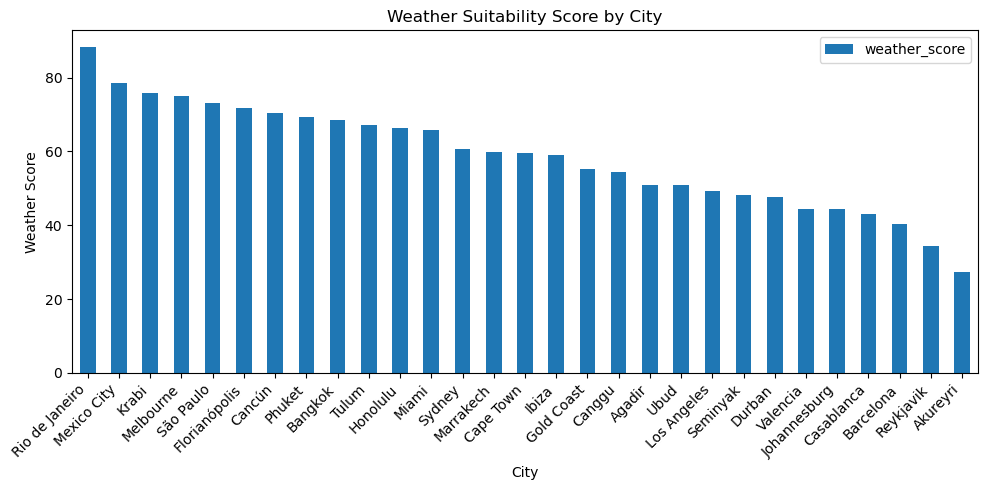

In [34]:
df_weather.sort_values("weather_score", ascending=False).plot(
    x="city",
    y="weather_score",
    kind="bar",
    figsize=(10, 5))

plt.title("Weather Suitability Score by City")
plt.xlabel("City")
plt.ylabel("Weather Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

- A weather suitability score was created to rank destinations using multiple weather variables rather than temperature alone. The score combines average maximum temperature, humidity, cloudiness, and wind speed to provide a more balanced recommendation.

- Higher scores indicate destinations with warmer, clearer, less windy, and more comfortable weather conditions.


In [36]:
top_10_weather = df_weather[[
    "city",
    "country",
    "weather_score",
    "weather_rating"]].head(10)

top_10_weather

,city,country,weather_score,weather_rating
9,Rio de Janeiro,Brazil,88.39,Excellent
2,Mexico City,Mexico,78.60,Excellent
17,Krabi,Thailand,75.76,Excellent
27,Melbourne,Australia,75.00,Excellent
10,São Paulo,Brazil,73.20,Good
11,Florianópolis,Brazil,71.74,Good
1,Cancún,Mexico,70.29,Good
15,Phuket,Thailand,69.35,Good
16,Bangkok,Thailand,68.43,Good
0,Tulum,Mexico,67.20,Good


In [37]:
df_weather = df_weather.reset_index(drop=True)
df_weather.index = df_weather.index + 1
df_weather.index.name = "rank"

df_weather[[
    "city",
    "country",
    "weather_score",
    "weather_rating"
]].head(10)

,city,country,weather_score,weather_rating
rank,,,,
1,Rio de Janeiro,Brazil,88.39,Excellent
2,Mexico City,Mexico,78.60,Excellent
3,Krabi,Thailand,75.76,Excellent
4,Melbourne,Australia,75.00,Excellent
5,São Paulo,Brazil,73.20,Good
6,Florianópolis,Brazil,71.74,Good
7,Cancún,Mexico,70.29,Good
8,Phuket,Thailand,69.35,Good
9,Bangkok,Thailand,68.43,Good
